<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<style>
/* format A4 horizontal + marges correctes à l’impression */
@page { size: A4 landscape; margin: 12mm; }
</style>
<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<style>
/* Page A4 horizontale + marge gauche minimale */
@page {
  size: A4 landscape;
  margin: 10mm 10mm 10mm 0mm; /* top right bottom left */
}
/* Supprimer les marges/paddings HTML résiduels */
html, body { margin: 0 !important; padding: 0 !important; }
/* Selon le thème nbconvert, enlève les marges internes du conteneur */
#notebook, .jp-Notebook, .container { margin-left: 0 !important; padding-left: 0 !important; }
</style>
<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
#Importation de matplotlib pour création graphique histogramme
import matplotlib.pyplot as plt
#Importation de matplotlib pour création graphique tableaux podium
import seaborn as sns

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))
population

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113
...,...,...,...
1411,Zimbabwe,2014,13586.707
1412,Zimbabwe,2015,13814.629
1413,Zimbabwe,2016,14030.331
1414,Zimbabwe,2017,14236.595


In [4]:
#Consulter le nombre de colonnes
nb_col = len(population.columns)
print("Nombre de colonnes :", nb_col)
#La nature des données dans chacune des colonnes
print(population.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
population.info(verbose=True)


Nombre de colonnes : 3
Zone       object
Année       int64
Valeur    float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


In [5]:
#Affichage les 5 premières lignes de la table
population.head()


,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population["Valeur"] = population["Valeur"] * 1000



In [7]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={"Valeur" : "Population"}, inplace=True)


In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [9]:
#Afficher les dimensions du dataset
print("Dimensions du dataset du fichier disponibilité alimentaire : {} lignes".format(dispo_alimentaire.shape[0]))
print("et {} colonnes".format(dispo_alimentaire.shape[1]))
dispo_alimentaire


Dimensions du dataset du fichier disponibilité alimentaire : 15605 lignes
et 18 colonnes


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,NaN,NaN,45.0,4.70,4.28,1.41,3.0,NaN,0.0,3.0,NaN,2.0,NaN,NaN,NaN
15601,Îles Salomon,Viande de Volailles,animale,NaN,NaN,11.0,3.34,0.69,1.14,2.0,NaN,2.0,2.0,NaN,0.0,NaN,NaN,NaN
15602,Îles Salomon,"Viande, Autre",animale,NaN,NaN,0.0,0.06,NaN,0.04,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
15603,Îles Salomon,Vin,vegetale,NaN,NaN,0.0,0.07,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [10]:
#Consulter le nombre de colonnes
nb_col = len(dispo_alimentaire.columns)
print("Nombre de colonnes :", nb_col)
dispo_alimentaire.info(verbose=True)

Nombre de colonnes : 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15605 entries, 0 to 15604
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           15605 non-null  object 
 1   Produit                                                        15605 non-null  object 
 2   Origine                                                        15605 non-null  object 
 3   Aliments pour animaux                                          2720 non-null   float64
 4   Autres Utilisations                                            5496 non-null   float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 14241 non-null  float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         14015 non-null  float64
 7   Disponibilité de matière grasse en

In [11]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [12]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0, inplace=True)

In [13]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
dispo_alimentaire ["Aliments pour animaux"] = dispo_alimentaire ["Aliments pour animaux"] * 1000
dispo_alimentaire ["Autres Utilisations"] = dispo_alimentaire ["Autres Utilisations"] * 1000
dispo_alimentaire ["Disponibilité intérieure"] = dispo_alimentaire ["Disponibilité intérieure"] * 1000
dispo_alimentaire ["Exportations - Quantité"] = dispo_alimentaire ["Exportations - Quantité"] * 1000
dispo_alimentaire ["Importations - Quantité"] = dispo_alimentaire ["Importations - Quantité"] * 1000
dispo_alimentaire ["Nourriture"] = dispo_alimentaire ["Nourriture"] * 1000
dispo_alimentaire ["Pertes"] = dispo_alimentaire ["Pertes"] * 1000
dispo_alimentaire ["Production"] = dispo_alimentaire ["Production"] * 1000
dispo_alimentaire ["Semences"] = dispo_alimentaire ["Semences"] * 1000
dispo_alimentaire ["Traitement"] = dispo_alimentaire ["Traitement"] * 1000
dispo_alimentaire ["Variation de stock"] = dispo_alimentaire ["Variation de stock"] * 1000


In [14]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [15]:
#Afficher les dimensions du dataset
print("Dimensions du dataset du fichier aide alimentaire : {} lignes".format(aide_alimentaire.shape[0]))
print("et {} colonnes".format(aide_alimentaire.shape[1]))
aide_alimentaire


Dimensions du dataset du fichier aide alimentaire : 1475 lignes
et 4 colonnes


,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504
...,...,...,...,...
1470,Zimbabwe,2015,Mélanges et préparations,96
1471,Zimbabwe,2013,Non-céréales,5022
1472,Zimbabwe,2014,Non-céréales,2310
1473,Zimbabwe,2015,Non-céréales,306


In [16]:
#Consulter le nombre de colonnes
nb_col = len(dispo_alimentaire.columns)
print("Nombre de colonnes :", nb_col)
aide_alimentaire.info(verbose=True)


Nombre de colonnes : 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Pays bénéficiaire  1475 non-null   object
 1   Année              1475 non-null   int64 
 2   Produit            1475 non-null   object
 3   Valeur             1475 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.2+ KB


In [17]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()


,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [18]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={"Pays bénéficiaire" : "Zone"}, inplace=True)


In [19]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire.rename(columns={"Valeur" : "Aide alimentaire"}, inplace=True)
aide_alimentaire["Aide alimentaire"] = aide_alimentaire["Aide alimentaire"] * 1000

In [20]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()


,Zone,Année,Produit,Aide alimentaire
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [21]:
#Afficher les dimensions du dataset
print("Dimensions du dataset du fichier sous nutrition : {} lignes".format(sous_nutrition.shape[0]))
print("et {} colonnes".format(sous_nutrition.shape[1]))
sous_nutrition

Dimensions du dataset du fichier sous nutrition : 1218 lignes
et 3 colonnes


,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5
...,...,...,...
1213,Zimbabwe,2013-2015,NaN
1214,Zimbabwe,2014-2016,NaN
1215,Zimbabwe,2015-2017,NaN
1216,Zimbabwe,2016-2018,NaN


In [22]:
#Consulter le nombre de colonnes
nb_col = len(sous_nutrition.columns)
print("Nombre de colonnes :", nb_col)
sous_nutrition.info(verbose=True)

Nombre de colonnes : 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Zone    1218 non-null   object
 1   Année   1218 non-null   object
 2   Valeur  624 non-null    object
dtypes: object(3)
memory usage: 28.7+ KB


In [23]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [24]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={"Valeur":"Sous nutrition"})


In [25]:
#Conversion de la colonne sous nutrition en numérique
#sous_nutrition['Sous nutrition'] = pd.to_numeric(sous_nutrition['Sous nutrition'])
#Conversion de la colonne sous nutrition en numérique avec l'argument errors=coerce
#sous_nutrition["Sous nutrition"] = pd.to_numeric(sous_nutrition["Sous nutrition"], errors="coerce")


In [26]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition["Sous nutrition"] = pd.to_numeric(sous_nutrition["Sous nutrition"], errors="coerce")
#Puis remplacement des NaN en 0
sous_nutrition = sous_nutrition.replace("<0.1", 0)
sous_nutrition.fillna(0, inplace=True)



In [27]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition ["Sous nutrition"] = sous_nutrition ["Sous nutrition"] * 1000000

In [28]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Sous nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [29]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
personnes_sous_nutrition_2017 = pd.merge(population.loc[population["Année"] == 2017,["Zone", "Population"]], 
                                                    sous_nutrition.loc[sous_nutrition["Année"] == "2016-2018", ["Zone", "Sous nutrition"]],
                                                    on="Zone",          # clé de jointure
                                                    how="inner"         # garde seulement les zones communes
                                                   )


In [30]:
#Affichage du dataset
personnes_sous_nutrition_2017

,Zone,Population,Sous nutrition
0,Afghanistan,36296113.0,10500000.0
1,Afrique du Sud,57009756.0,3100000.0
2,Albanie,2884169.0,100000.0
3,Algérie,41389189.0,1300000.0
4,Allemagne,82658409.0,0.0
...,...,...,...
198,Venezuela (République bolivarienne du),29402484.0,8000000.0
199,Viet Nam,94600648.0,6500000.0
200,Yémen,27834819.0,0.0
201,Zambie,16853599.0,0.0


In [31]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
nombre_personnes_sous_nutrition_2017 = personnes_sous_nutrition_2017["Sous nutrition"].sum()
print("Le nombre de personnes en état de sous-nutrition en 2017 est de", "{:.0f}".format(nombre_personnes_sous_nutrition_2017))

#Calcul et affichage du nombre de personnes en état de sous nutrition en pourcentage %
proportion_personnes_sous_nutrition_2017 = nombre_personnes_sous_nutrition_2017/personnes_sous_nutrition_2017["Population"].sum() * 100
print("Le proportion de personnes en état de sous-nutrition en 2017 est de", "{:.0f}%".format(proportion_personnes_sous_nutrition_2017))


Le nombre de personnes en état de sous-nutrition en 2017 est de 535700000
Le proportion de personnes en état de sous-nutrition en 2017 est de 7%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [32]:
#Combien mange en moyenne un être humain ? Source => https://www.nutrimuscle.com/blogs/actualites/combien-de-calories-par-jour
print("Source des données pour Combien mange en moyenne un être humain ?  : https://www.nutrimuscle.com/blogs/actualites/combien-de-calories-par-jour")
print("Les besoins énergétiques quotidiens en moyenne pour une femme sont estimés à 2000 Kcal/jour")
print("Les besoins énergétiques quotidiens en moyenne pour un homme sont estimés à 2500 Kcal/jour")

#Moyenne pour un etre humain en Kcal/jour
moyenne_kcal_personne = (2000 + 2500)/2
print("Un être humain mange en moyenne", "{:.0f}".format(moyenne_kcal_personne),"Kcal/jour")


Source des données pour Combien mange en moyenne un être humain ?  : https://www.nutrimuscle.com/blogs/actualites/combien-de-calories-par-jour
Les besoins énergétiques quotidiens en moyenne pour une femme sont estimés à 2000 Kcal/jour
Les besoins énergétiques quotidiens en moyenne pour un homme sont estimés à 2500 Kcal/jour
Un être humain mange en moyenne 2250 Kcal/jour


In [33]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
dispo_alimentaire = dispo_alimentaire.merge(population.loc[population["Année"] == 2017,["Zone", "Population"]], 
                                            how = "inner", 
                                            on = "Zone")

In [34]:
#Affichage du nouveau dataframe
dispo_alimentaire

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000.0,0.0,0.0,3000.0,0.0,2000.0,0.0,0.0,0.0,636039.0
15412,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,636039.0
15413,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0
15414,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0


In [35]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dispo_alimentaire["dispo_kcal"] = dispo_alimentaire["Disponibilité alimentaire (Kcal/personne/jour)"] * dispo_alimentaire["Population"] * 365
print("Calcul des kcal dispo_kcal disponibles mondialement :","{:.0f}".format(dispo_alimentaire["dispo_kcal"].sum()), "Kcal")

Calcul des kcal dispo_kcal disponibles mondialement : 7635429388975815 Kcal


In [36]:
#Calcul du nombre d'humains pouvant être nourris
nombre_humains_nourris = round(dispo_alimentaire["dispo_kcal"].sum()/(moyenne_kcal_personne * 365))
print("Le nombre d'humains pouvant être nourris en 2017 est de :", nombre_humains_nourris)

#Calcul du nombre d'humains pouvant être nourris en pourcentage
proportion_humains_kcal = nombre_humains_nourris * 100/population.loc[population["Année"] == 2017,"Population"].sum()
print("La proportion d'humains pouvant être nourris en 2017 est de", "{:.0f}".format(proportion_humains_kcal), "%")


Le nombre d'humains pouvant être nourris en 2017 est de : 9297326501
La proportion d'humains pouvant être nourris en 2017 est de 123 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [37]:
#Transfert des données avec les végétaux dans un nouveau dataframe
vegetaux = dispo_alimentaire.loc[dispo_alimentaire["Origine"] == "vegetale",:]

In [38]:
#Calcul du nombre de kcal disponible pour les végétaux
kcal_dispo_vegetaux = vegetaux["dispo_kcal"].sum()
print("Nombre de Kcal disponibles pour les végétaux :", kcal_dispo_vegetaux)

Nombre de Kcal disponibles pour les végétaux : 6300178937197865.0


In [39]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
vegetaux_kcal_total = round(vegetaux["dispo_kcal"].sum()/(moyenne_kcal_personne * 365))
print("Le nombre d'humains pouvant être nourris en 2017 est de : ", vegetaux_kcal_total, "humains")
#Calcul du nombre d'humains pouvant être nourris avec les végétaux en pourcentage/proportion
prop_vegetaux_kcal = vegetaux_kcal_total * 100/population.loc[population["Année"] == 2017,"Population"].sum()
print("La proportion d'humains pouvant être nourris avec les végétaux en 2017 est de", "{:.0f}".format(prop_vegetaux_kcal), "%")

Le nombre d'humains pouvant être nourris en 2017 est de :  7671450761 humains
La proportion d'humains pouvant être nourris avec les végétaux en 2017 est de 102 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [40]:
#Calcul de la disponibilité totale
disponibilite_interieure_somme=dispo_alimentaire["Disponibilité intérieure"].sum()
print("La disponibilité totale est de", "{:.0f} tonnes".format(disponibilite_interieure_somme)) 

La disponibilité totale est de 9733927000 tonnes


In [41]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
colonnes=['Aliments pour animaux','Pertes','Nourriture']
for col in colonnes:
    prop_col_totale = dispo_alimentaire[col].sum()
    print("Total ", col, ":", prop_col_totale)

Total  Aliments pour animaux : 1288002000.0
Total  Pertes : 452283000.0
Total  Nourriture : 4805525000.0


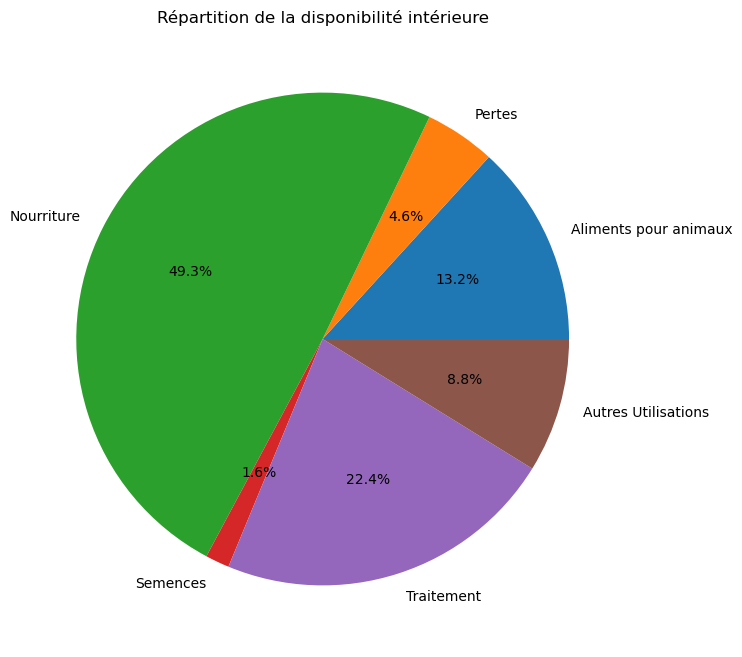

In [42]:
# Définition des Proportions
proportion_aliments_animaux=dispo_alimentaire['Aliments pour animaux'].sum()/disponibilite_interieure_somme*100
proportion_Perte=dispo_alimentaire['Pertes'].sum()/disponibilite_interieure_somme*100
proportion_Nourriture=dispo_alimentaire['Nourriture'].sum()/disponibilite_interieure_somme*100
proportion_Semence=dispo_alimentaire['Semences'].sum()/disponibilite_interieure_somme*100
proportion_Traitement=dispo_alimentaire['Traitement'].sum()/disponibilite_interieure_somme*100
proportion_Autres_Utilisations=dispo_alimentaire['Autres Utilisations'].sum()/disponibilite_interieure_somme*100

# Labels pour chaque segment du camembert
labels = [
    "Aliments pour animaux",
    "Pertes",
    "Nourriture",
    "Semences",
    "Traitement",
    "Autres Utilisations"
]

# Proportions correspondantes
proportions = [
    proportion_aliments_animaux,
    proportion_Perte,
    proportion_Nourriture,
    proportion_Semence,
    proportion_Traitement,
    proportion_Autres_Utilisations
]

# Création du camembert
plt.figure(figsize=(8, 8))
plt.pie(proportions, labels=labels, autopct='%1.1f%%')

# Titre du camembert
plt.title('Répartition de la disponibilité intérieure')

# Affichage du camembert
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [43]:
#Création d'une liste avec toutes les variables
liste_variables=dispo_alimentaire['Produit'].unique()
print(liste_variables)

['Abats Comestible' 'Agrumes, Autres' 'Aliments pour enfants' 'Ananas'
 'Bananes' 'Beurre, Ghee' 'Bière' 'Blé' 'Boissons Alcooliques' 'Café'
 'Coco (Incl Coprah)' 'Crème' 'Céréales, Autres' 'Dattes'
 'Edulcorants Autres' 'Feve de Cacao' 'Fruits, Autres' 'Graines de coton'
 'Graines de tournesol' 'Graisses Animales Crue' 'Huil Plantes Oleif Autr'
 'Huile Graines de Coton' "Huile d'Arachide" "Huile d'Olive"
 'Huile de Colza&Moutarde' 'Huile de Palme' 'Huile de Soja'
 'Huile de Sésame' 'Huile de Tournesol' 'Lait - Excl Beurre'
 'Légumes, Autres' 'Légumineuses Autres' 'Maïs' 'Miel' 'Millet'
 'Miscellanees' 'Noix' 'Oeufs' 'Olives' 'Oranges, Mandarines' 'Orge'
 'Plantes Oleiferes, Autre' 'Poissons Eau Douce' 'Poivre' 'Pommes'
 'Pommes de Terre' 'Raisin' 'Riz (Eq Blanchi)' 'Sucre Eq Brut'
 'Sucre, betterave' 'Sucre, canne' 'Sésame' 'Thé' 'Tomates'
 "Viande d'Ovins/Caprins" 'Viande de Bovins' 'Viande de Volailles'
 'Viande, Autre' 'Vin' 'Épices, Autres' 'Alcool, non Comestible'
 'Animaux Aquat

In [44]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
liste_cereales = ['Blé', 'Céréales', 'Maïs', 'Millet', 'Orge','Riz (Eq Blanchi)','Avoine','Seigle','Sorgho','Céréales, Autres']
cereales = dispo_alimentaire.loc[dispo_alimentaire["Produit"].isin(liste_cereales), :]
cereales


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5992000.0,0.0,1173000.0,4895000.0,775000.0,5169000.0,322000.0,0.0,-350000.0,36296113.0,1.813662e+13
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.000000e+00
32,Afghanistan,Maïs,vegetale,200000.0,0.0,21.0,2.50,0.30,0.56,313000.0,0.0,1000.0,76000.0,31000.0,312000.0,5000.0,0.0,0.0,36296113.0,2.782097e+11
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,13000.0,0.0,0.0,12000.0,1000.0,13000.0,0.0,0.0,0.0,36296113.0,3.974424e+10
40,Afghanistan,Orge,vegetale,360000.0,0.0,26.0,2.92,0.24,0.79,524000.0,0.0,10000.0,89000.0,52000.0,514000.0,22000.0,0.0,0.0,36296113.0,3.444501e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15356,Îles Salomon,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0,0.000000e+00
15379,Îles Salomon,Maïs,vegetale,0.0,0.0,1.0,0.15,0.01,0.03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0,2.321542e+08
15386,Îles Salomon,Orge,vegetale,0.0,0.0,0.0,0.07,0.00,0.01,1000.0,0.0,1000.0,0.0,0.0,0.0,0.0,1000.0,0.0,636039.0,0.000000e+00
15402,Îles Salomon,Riz (Eq Blanchi),vegetale,0.0,12000.0,623.0,63.76,1.36,10.90,49000.0,0.0,47000.0,36000.0,1000.0,3000.0,0.0,0.0,0.0,636039.0,1.446321e+11


In [45]:
#Affichage de la proportion d'alimentation animale
proportion_cereales_animaux = cereales["Aliments pour animaux"].sum()/cereales["Disponibilité intérieure"].sum() * 100
print("La proportion de céréales pour l'alimentaire animale est de", "{:.0f} %".format(proportion_cereales_animaux))

La proportion de céréales pour l'alimentaire animale est de 36 %


In [46]:
#Affichage de la proportion d'alimentation humaine
proportion_cereales_humains = cereales["Nourriture"].sum()/cereales["Disponibilité intérieure"].sum() * 100
print("La proportion de céréales pour l'alimentaire animale est de", "{:.0f} %".format(proportion_cereales_humains))

La proportion de céréales pour l'alimentaire animale est de 43 %


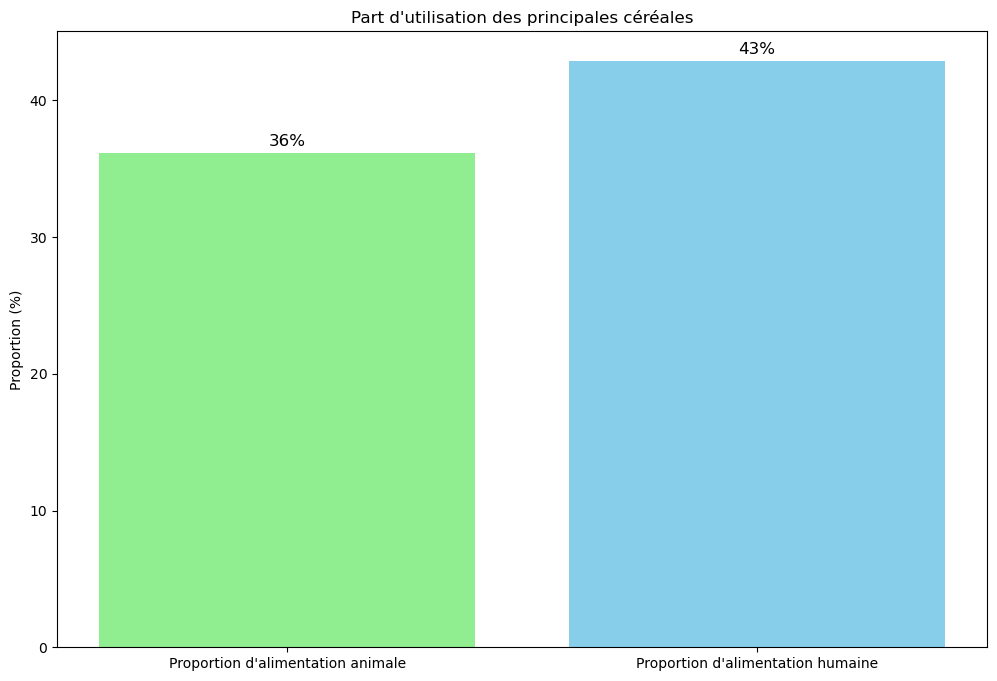

In [47]:
#Graphique histogramme des proportions alimentaire animale et humaine
proportion_cereales_animaux = cereales["Aliments pour animaux"].sum()/cereales["Disponibilité intérieure"].sum() * 100
proportion_cereales_humains = cereales["Nourriture"].sum()/cereales["Disponibilité intérieure"].sum() * 100
labels = [ "Proportion d'alimentation animale", "Proportion d'alimentation humaine"]
proportions = [ proportion_cereales_animaux, proportion_cereales_humains]
plt.figure(figsize=(12, 8))
plt.bar(labels, proportions, color=['lightgreen', 'skyblue'])
plt.title('Part d\'utilisation des principales céréales')
plt.ylabel('Proportion (%)')
for i, value in enumerate(proportions):
    plt.text(i, value + 0.5, f'{value:.0f}%', ha='center', fontsize=12)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [48]:
#Création de la colonne proportion par pays
personnes_sous_nutrition_2017["Proportion par pays"] = personnes_sous_nutrition_2017["Sous nutrition"]/personnes_sous_nutrition_2017["Population"] * 100


In [49]:
#affichage après trie des 10 pires pays
personnes_sous_nutrition_2017_top10_pire_pays = personnes_sous_nutrition_2017.sort_values("Proportion par pays", ascending=False)
personnes_sous_nutrition_2017_top10_pire_pays.head(10)

,Zone,Population,Sous nutrition,Proportion par pays
78,Haïti,10982366.0,5300000.0,48.259182
157,République populaire démocratique de Corée,25429825.0,12000000.0,47.188685
108,Madagascar,25570512.0,10500000.0,41.062924
103,Libéria,4702226.0,1800000.0,38.279742
100,Lesotho,2091534.0,800000.0,38.249438
183,Tchad,15016753.0,5700000.0,37.957606
161,Rwanda,11980961.0,4200000.0,35.055619
121,Mozambique,28649018.0,9400000.0,32.810898
186,Timor-Leste,1243258.0,400000.0,32.173531
0,Afghanistan,36296113.0,10500000.0,28.928718


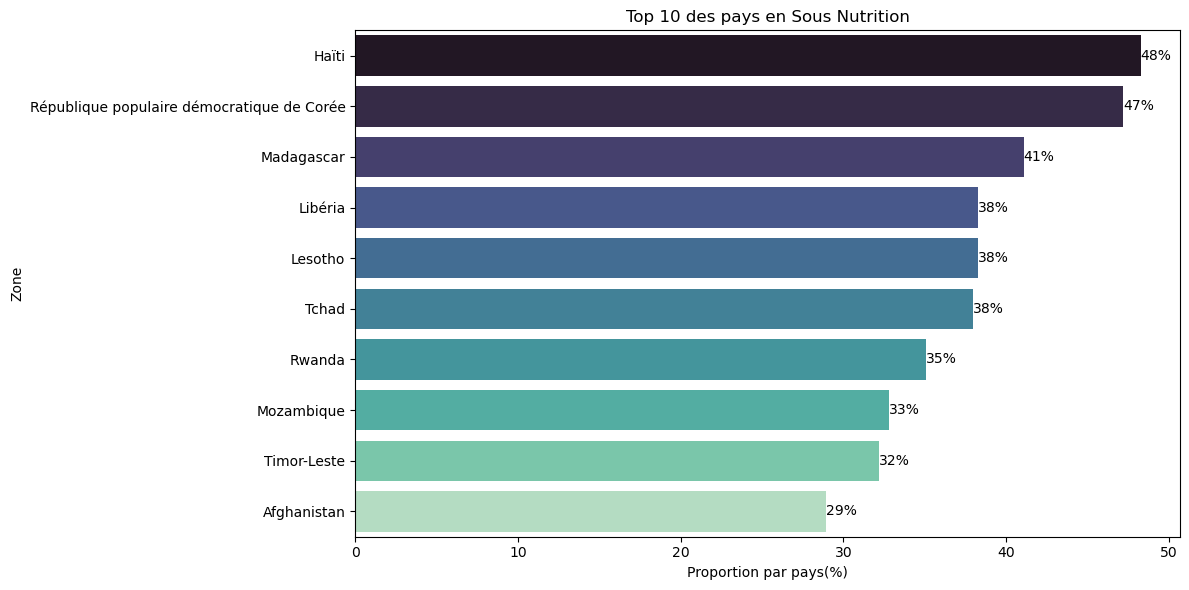

In [50]:
#Top 10 des pays avec la proportion de personnes sous-alimentée la plus forte en 2017
# Horizontal Bar Plot
#personnes_sous_nutrition_2017_top10_pire_pays.head(10).groupby("Zone")["Proportion par pays"].sum().sort_values().plot.barh(color="blue", 
#figsize=(8,8), title="Top 10 des pays ou la proportion de personnes sous-alimentée la plus forte en 2017");

#Top 10 des pays avec la proportion de personnes sous-alimentée la plus forte en 2017
# Horizontal Bar Plot

plt.figure(figsize=(12, 6))
sns.barplot(x='Proportion par pays', y='Zone', data=personnes_sous_nutrition_2017_top10_pire_pays.head(10), hue='Zone', palette='mako')
plt.xlabel('Proportion par pays(%)')
plt.ylabel('Zone')
plt.title('Top 10 des pays en Sous Nutrition')
for index, value in enumerate(personnes_sous_nutrition_2017_top10_pire_pays.head(10)['Proportion par pays']):
    plt.text(value, index, f'{value:.0f}%', va='center')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [51]:
#calcul du total de l'aide alimentaire par pays
aide_alimentaire_par_pays = aide_alimentaire[["Zone", "Aide alimentaire"]].groupby("Zone").sum().reset_index()
aide_alimentaire_par_pays["Aide alimentaire"] = (aide_alimentaire_par_pays["Aide alimentaire"].div(1000000).round(2))

In [52]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
aide_alimentaire_par_pays.sort_values("Aide alimentaire", ascending=False, inplace=True)
aide_alimentaire_par_pays.head(10)

,Zone,Aide alimentaire
50,République arabe syrienne,1858.94
75,Éthiopie,1381.29
70,Yémen,1206.48
61,Soudan du Sud,695.25
60,Soudan,669.78
30,Kenya,552.84
3,Bangladesh,348.19
59,Somalie,292.68
53,République démocratique du Congo,288.50
43,Niger,276.34


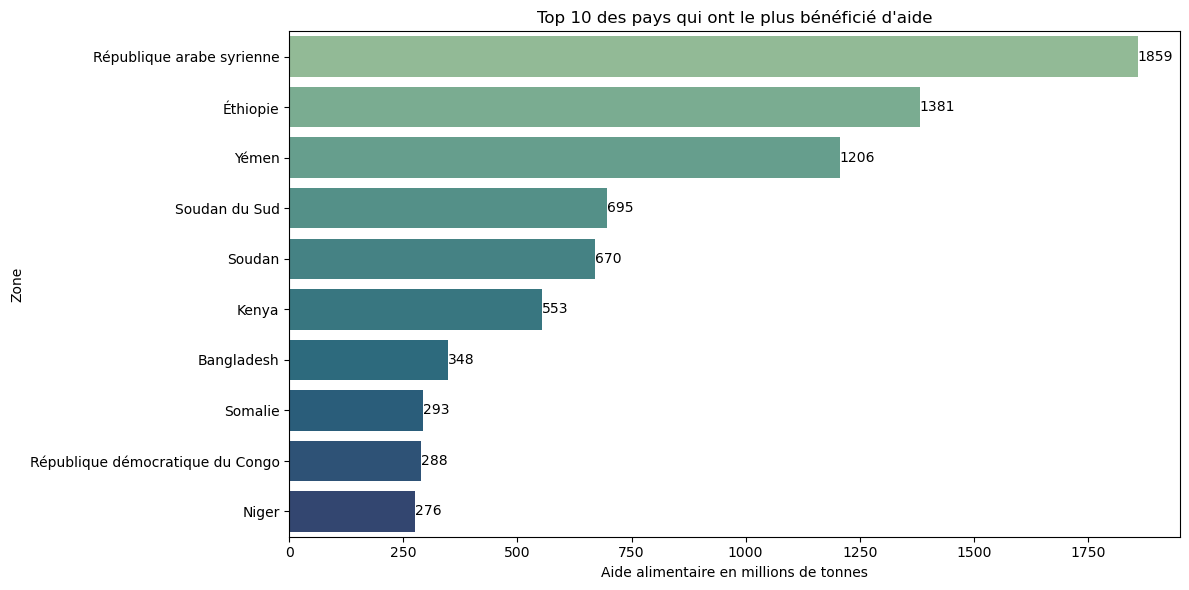

In [53]:
#Top 10 des pays avec la proportion de personnes sous-alimentée la plus forte en 2017
# Horizontal Bar Plot
#aide_alimentaire_par_pays.head(10).groupby("Zone")["Aide alimentaire"].sum().sort_values().plot.barh(
#color="red", figsize=(8,8), title="Top 10 des pays qui ont le plus bénéficié d'aide alimentaire depuis 2013");

#Top 10 des pays avec la proportion de personnes sous-alimentée la plus forte en 2017
# Horizontal Bar Plot
# Test Seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=aide_alimentaire_par_pays.head(10),
    x='Aide alimentaire', y='Zone',
    hue='Zone',           # <- clé pour autoriser palette
    palette='crest',
    dodge=False,
    legend=False          # pas besoin de légende (hue == y)
)
plt.xlabel('Aide alimentaire en millions de tonnes')
plt.ylabel('Zone')
plt.title("Top 10 des pays qui ont le plus bénéficié d'aide")

# Annotation robuste directement sur les barres
for p in ax.patches:
    x = p.get_width()
    y = p.get_y() + p.get_height()/2
    ax.text(x, y, f'{x:.0f}', va='center', ha='left')

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [54]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
pays_beneficiaires_aide_alimentaire = aide_alimentaire[["Zone", "Année", "Aide alimentaire"]]
pays_beneficiaires_aide_alimentaire = pays_beneficiaires_aide_alimentaire.groupby(["Zone", "Année"]).sum().reset_index()

In [55]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
top5_pays_beneficiaires_aide_alimentaire = aide_alimentaire_par_pays["Zone"].head().tolist()
top5_pays_beneficiaires_aide_alimentaire

['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [56]:
#On filtre sur le dataframe avec notre liste
pays_beneficiaires_aide_alimentaire = pays_beneficiaires_aide_alimentaire.loc[pays_beneficiaires_aide_alimentaire["Zone"].isin(top5_pays_beneficiaires_aide_alimentaire), :]

In [57]:
# Affichage des pays avec l'aide alimentaire par année
pays_beneficiaires_aide_alimentaire

,Zone,Année,Aide alimentaire
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


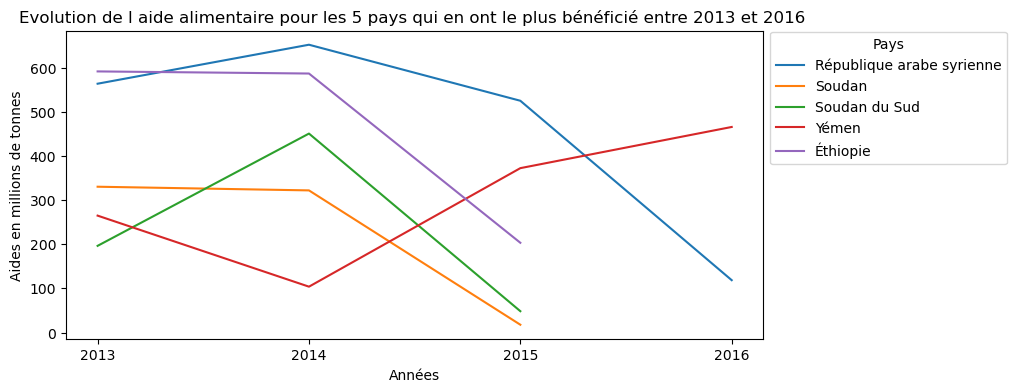

In [58]:
## Création du graphique de variation
## Divisons les aides pour avoir une vue en milliers de tonnes, plus agréable à la lecture.
pays_beneficiaires_aide_alimentaire['Aide alimentaire']/= 1000000

## Création du graphique 
plt.figure(figsize=(9,4)) 

## Création de la boucle for pour grouper les courbes par "zone" 
for i,r in pays_beneficiaires_aide_alimentaire.groupby('Zone'):
    plt.plot(r['Année'], r['Aide alimentaire'], label=i)

plt.xticks([2013, 2014, 2015, 2016])
plt.title('Evolution de l aide alimentaire pour les 5 pays qui en ont le plus bénéficié entre 2013 et 2016 ')
plt.xlabel('Années')
plt.ylabel('Aides en millions de tonnes')
plt.legend(title="Pays", bbox_to_anchor=(1, 1.02)) # On place la légende en dehors du graphique avec bbox_to_anchor

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [59]:
#Calcul de la disponibilité en kcal par personne par jour par pays
disponibilite_kcal_personne_jour_pays = dispo_alimentaire[["Zone","Produit","Disponibilité alimentaire (Kcal/personne/jour)"]].groupby("Zone").sum()

In [60]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
disponibilite_kcal_personne_jour_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=True, inplace=True)
disponibilite_kcal_personne_jour_pays.head(10)

,Produit,Disponibilité alimentaire (Kcal/personne/jour)
Zone,,
République centrafricaine,"Abats ComestibleAlcool, non ComestibleAliments...",1879.0
Zambie,"Abats ComestibleAgrumes, AutresAlcool, non Com...",1924.0
Madagascar,"Abats ComestibleAgrumes, AutresAlcool, non Com...",2056.0
Afghanistan,"Abats ComestibleAgrumes, AutresAliments pour e...",2087.0
Haïti,"Abats ComestibleAgrumes, AutresAlcool, non Com...",2089.0
République populaire démocratique de Corée,Abats ComestibleAnimaux Aquatiques AutreAvoine...,2093.0
Tchad,"Abats ComestibleAlcool, non ComestibleAliments...",2109.0
Zimbabwe,"Abats ComestibleAgrumes, AutresAlcool, non Com...",2113.0
Ouganda,"Abats ComestibleAgrumes, AutresAlcool, non Com...",2126.0


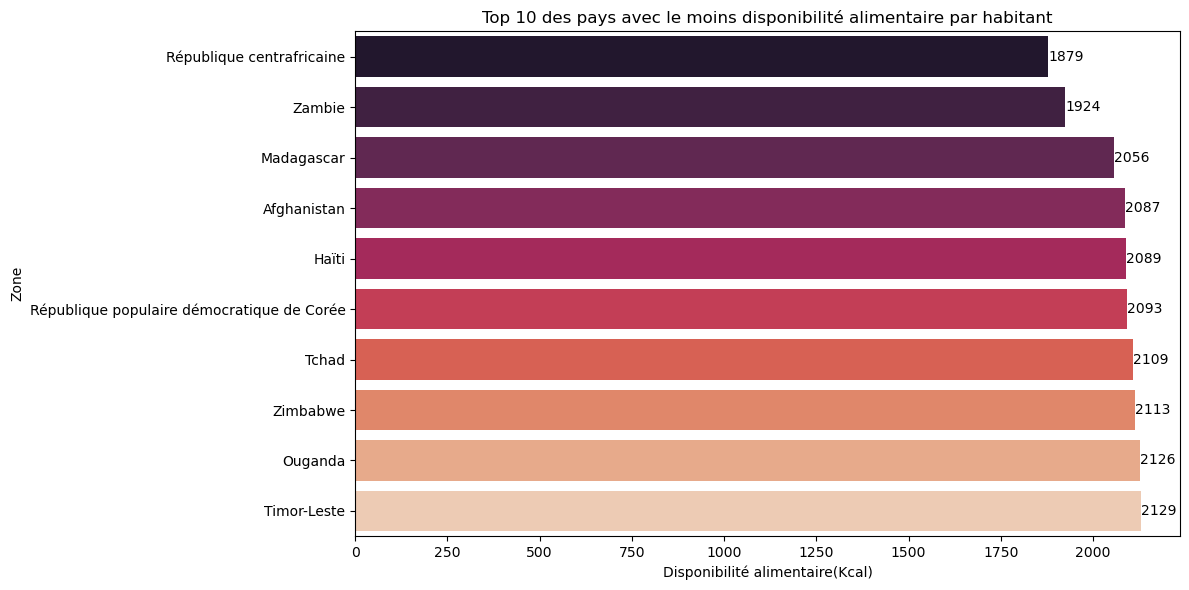

In [61]:
disponibilite_kcal_personne_jour_pays.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)',ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='Disponibilité alimentaire (Kcal/personne/jour)', y='Zone', hue ='Zone', data=disponibilite_kcal_personne_jour_pays.head(10), palette='rocket')
plt.xlabel('Disponibilité alimentaire(Kcal)')
plt.ylabel('Zone')
plt.title('Top 10 des pays avec le moins disponibilité alimentaire par habitant')
for index, value in enumerate(disponibilite_kcal_personne_jour_pays.head(10)['Disponibilité alimentaire (Kcal/personne/jour)']):
    plt.text(value, index, f'{value:.0f}', va='center')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [62]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
disponibilite_kcal_personne_jour_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False, inplace=True)
disponibilite_kcal_personne_jour_pays.head(10)

,Produit,Disponibilité alimentaire (Kcal/personne/jour)
Zone,,
Autriche,"Abats ComestibleAgrumes, AutresAlcool, non Com...",3770.0
Belgique,"Abats ComestibleAgrumes, AutresAlcool, non Com...",3737.0
Turquie,"Abats ComestibleAgrumes, AutresAlcool, non Com...",3708.0
États-Unis d'Amérique,"Abats ComestibleAgrumes, AutresAlcool, non Com...",3682.0
Israël,"Abats ComestibleAgrumes, AutresAlcool, non Com...",3610.0
Irlande,"Abats ComestibleAgrumes, AutresAlcool, non Com...",3602.0
Italie,"Abats ComestibleAgrumes, AutresAlcool, non Com...",3578.0
Luxembourg,"Abats ComestibleAgrumes, AutresAlcool, non Com...",3540.0
Égypte,"Abats ComestibleAgrumes, AutresAlcool, non Com...",3518.0


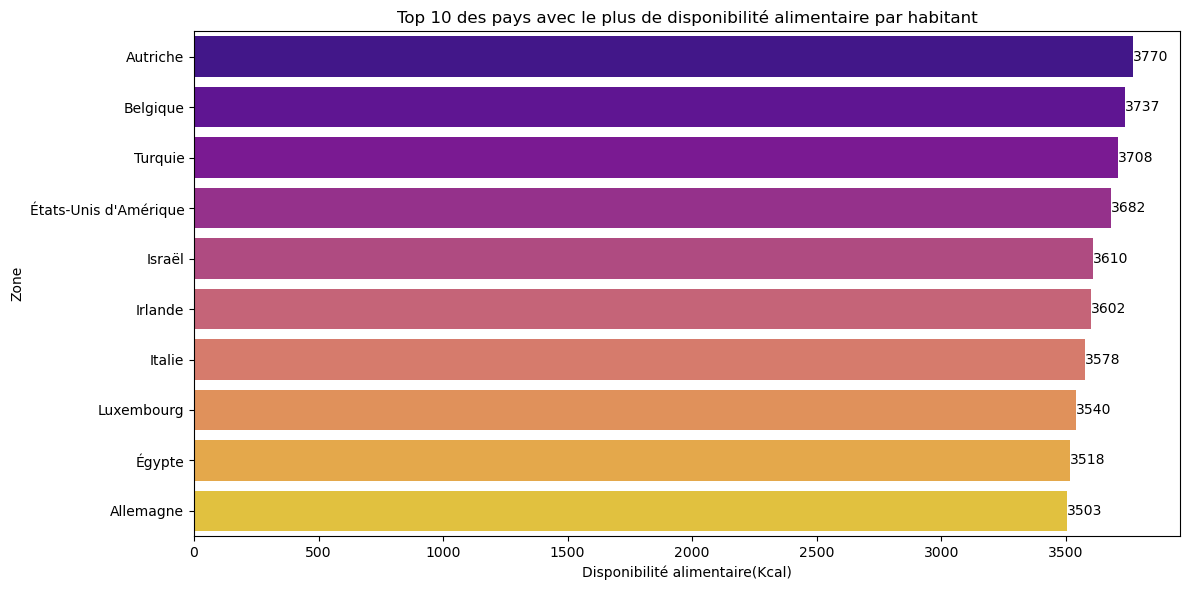

In [63]:
#Graphique bar chart du top 10 des pays avec le plus de disponibilié par habitant
disponibilite_kcal_personne_jour_pays.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)',ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='Disponibilité alimentaire (Kcal/personne/jour)', y='Zone', data=disponibilite_kcal_personne_jour_pays.head(10), hue= 'Zone', palette='plasma')
plt.xlabel('Disponibilité alimentaire(Kcal)')
plt.ylabel('Zone')
plt.title('Top 10 des pays avec le plus de disponibilité alimentaire par habitant')
for index, value in enumerate(disponibilite_kcal_personne_jour_pays.head(10)['Disponibilité alimentaire (Kcal/personne/jour)']):
    plt.text(value, index, f'{value:.0f}', va='center')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [64]:
#création d'un dataframe avec uniquement la Thaïlande 
thailande = personnes_sous_nutrition_2017.loc[personnes_sous_nutrition_2017["Zone"] == "Thaïlande",:]
thailande

,Zone,Population,Sous nutrition,Proportion par pays
185,Thaïlande,69209810.0,6200000.0,8.958268


In [65]:
#Calcul de la sous nutrition en Thaïlande
sous_nutrition_thailande = thailande["Sous nutrition"].sum()
print("La sous nutrition en Thaïlande est de", "{:.0f}".format(sous_nutrition_thailande))

#On joint les datasets et on sélectionne la ligne correspondant à la Thaïlande
dispo_population = pd.merge(population, sous_nutrition, on = "Zone")
dispo_population_thailande = dispo_population[dispo_population["Zone"] == "Thaïlande"]

#Calcul de la part de la population en état de sous-nutrition
part_sous_nutrition = (dispo_population_thailande.iloc[0]["Sous nutrition"] / dispo_population_thailande.iloc[0]["Population"]) * 100
print("En Thaïlande,", "{:.0f}".format(part_sous_nutrition),"% de la population est en état de sous nutrition")


La sous nutrition en Thaïlande est de 6200000
En Thaïlande, 9 % de la population est en état de sous nutrition


In [66]:
proportion_exportee_manioc = dispo_alimentaire.loc[(dispo_alimentaire["Produit"] == "Manioc") & (dispo_alimentaire["Zone"] == "Thaïlande"),:]

#Affichage de la quantité de manioc exportée de Thaïlande
quantite_manioc_exportee_thailande = proportion_exportee_manioc["Exportations - Quantité"].iloc[0]
print("La quantité de manioc exportée en Thaïlande est de plus de", "{:.0f}".format(quantite_manioc_exportee_thailande/1000000), "millions de kilos")


#Calculer la proportion exportée de manioc en fonction de la production totale en Thaïlande
pourcentage_manioc_exporte = proportion_exportee_manioc["Exportations - Quantité"].iloc[0] * 100 / proportion_exportee_manioc["Production"].iloc[0]
print("La proportion exportée de manioc en Thaïlande est de plus de", "{:.0f}".format(pourcentage_manioc_exporte), "%")

La quantité de manioc exportée en Thaïlande est de plus de 25 millions de kilos
La proportion exportée de manioc en Thaïlande est de plus de 83 %


In [67]:
#disponibilité par habitant pour la Thaïlande
dispo_kcal_pers_jr_Thai = dispo_alimentaire.loc[dispo_alimentaire["Zone"] == "Thaïlande", "Disponibilité alimentaire (Kcal/personne/jour)"].sum()
print("La disponibilité alimentaire par habitant pour la Thaïlande est de {} Kcal/jour".format(dispo_kcal_pers_jr_Thai))


La disponibilité alimentaire par habitant pour la Thaïlande est de 2785.0 Kcal/jour


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [68]:
#Ajout en dessous de toutes les analyses complémtaires qui semblent pertinents, graphiques, logique
#Toutes les informations utiles pour mettre en avant les pays qui semblent etre le plus en difficulté au niveau alimentaire et sous nutrition

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">6.1 - Evolution de la population en état de sous-nutrition en Thailande</h3>
</div>

In [69]:
#Remplacement des intervalles d'année en leur moyenne. 
#Tableau représentant la population en état de sous nutrition en thailande
sous_nutrition['Année'] = sous_nutrition['Année'].str.replace('2012-2014', '2013')
sous_nutrition['Année'] = sous_nutrition['Année'].str.replace('2013-2015', '2014')
sous_nutrition['Année'] = sous_nutrition['Année'].str.replace('2014-2016', '2015')
sous_nutrition['Année'] = sous_nutrition['Année'].str.replace('2015-2017', '2016')
sous_nutrition['Année'] = sous_nutrition['Année'].str.replace('2016-2018', '2017')
sous_nutrition['Année'] = sous_nutrition['Année'].str.replace('2017-2019', '2018')
df_thai=sous_nutrition.loc[sous_nutrition['Zone']=='Thaïlande',:]
df_thai


,Zone,Année,Sous nutrition
1110,Thaïlande,2013,6200000.0
1111,Thaïlande,2014,6000000.0
1112,Thaïlande,2015,5900000.0
1113,Thaïlande,2016,6000000.0
1114,Thaïlande,2017,6200000.0
1115,Thaïlande,2018,6500000.0


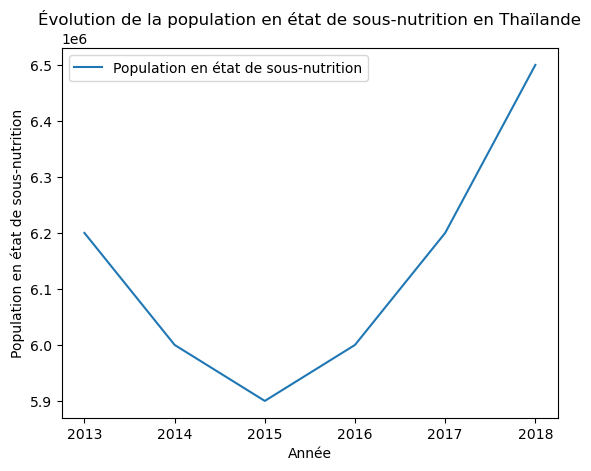

In [70]:
#Evolution de la population en état de sous-nutrition en Thailande
plt.plot(df_thai['Année'], df_thai['Sous nutrition'])
plt.title("Évolution de la population en état de sous-nutrition en Thaïlande")
plt.xlabel("Année")
plt.ylabel("Population en état de sous-nutrition")
plt.legend(["Population en état de sous-nutrition"])
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">6.2 - Les pays qui souffrent le plus de sous nutrition depuis 2013</h3>
</div>

In [71]:
# 1) S'assurer que la colonne est numérique
#somme de la population  en cumulé et nombre brut souffrant le plus de sous nutrition par pays (Zone):
sous_nutrition["Sous nutrition"] = pd.to_numeric(sous_nutrition["Sous nutrition"], errors="coerce")

# 2) Top 10 pays avec la plus forte population SOUS-NUTRITION (valeur brute)
#Les 10 pays dont la population souffre le plus de sous nutrition:
pays_forte_snutrition = (
    sous_nutrition
      .groupby("Zone", as_index=False)["Sous nutrition"].sum()
      .loc[lambda df: df["Sous nutrition"] > 0]
      .sort_values("Sous nutrition", ascending=False)
      .head(10)
)

# 3) Affichage
#On affiche la colonne souhaitée

(
    pays_forte_snutrition
      .style
      .format({"Sous nutrition": "{:,.0f}"})  # séparateurs de milliers
      .hide(axis="index")                      # masque l’index
      .set_caption("Top 10 des pays par population en sous-nutrition (valeur brute)")
)

Zone,Sous nutrition
Inde,"1,165,400,000"
Pakistan,"160,500,000"
Indonésie,"141,700,000"
Éthiopie,"136,100,000"
Bangladesh,"132,100,000"
Nigéria,"121,900,000"
Philippines,"93,300,000"
République-Unie de Tanzanie,"80,000,000"
République populaire démocratique de Corée,"68,100,000"
Kenya,"66,000,000"


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">6.3 - Les pays qui souffrent le moins de sous nutrition depuis 2013</h3>
</div>

In [72]:
#somme de la population en cumulé et nombre brut souffrant le moins de sous nutrition par pays (Zone)
#Les 10 pays dont la population souffre le moins de sous nutrition:
pays_faible_snutrition = (
    sous_nutrition.groupby("Zone", as_index=False)["Sous nutrition"].sum()
    .loc[lambda df: df["Sous nutrition"] > 0]
    .sort_values("Sous nutrition", ascending=True)
    .head(10)
)
# Affichage
#On affiche la colonne souhaitée
(pays_faible_snutrition
 .style
 .format({"Sous nutrition": "{:,.0f}"})   # milliers
 .hide(axis="index")                       # masque l’index
)

Zone,Sous nutrition
Cabo Verde,"100,000"
Kazakhstan,"500,000"
Albanie,"600,000"
Tunisie,"600,000"
Eswatini,"1,100,000"
Costa Rica,"1,200,000"
Turkménistan,"1,300,000"
Bulgarie,"1,400,000"
Géorgie,"1,400,000"
Gambie,"1,500,000"


In [73]:
#Proportion de la population sous-alimentée par zone
personnes_sous_nutrition_2017.head()

,Zone,Population,Sous nutrition,Proportion par pays
0,Afghanistan,36296113.0,10500000.0,28.928718
1,Afrique du Sud,57009756.0,3100000.0,5.437666
2,Albanie,2884169.0,100000.0,3.467203
3,Algérie,41389189.0,1300000.0,3.140917
4,Allemagne,82658409.0,0.0,0.000000


In [74]:
#Liste des 10 pays où la proportion de personnes sous-alimentées est la plus élevée
proportion_sous_ali = personnes_sous_nutrition_2017.sort_values(by='Proportion par pays', ascending=False).head(10)
proportion_sous_ali


,Zone,Population,Sous nutrition,Proportion par pays
78,Haïti,10982366.0,5300000.0,48.259182
157,République populaire démocratique de Corée,25429825.0,12000000.0,47.188685
108,Madagascar,25570512.0,10500000.0,41.062924
103,Libéria,4702226.0,1800000.0,38.279742
100,Lesotho,2091534.0,800000.0,38.249438
183,Tchad,15016753.0,5700000.0,37.957606
161,Rwanda,11980961.0,4200000.0,35.055619
121,Mozambique,28649018.0,9400000.0,32.810898
186,Timor-Leste,1243258.0,400000.0,32.173531
0,Afghanistan,36296113.0,10500000.0,28.928718


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">6.4 - Production exportation, importation et proportion export globale</h3>
</div>

In [75]:
#Production exportation, importation et proportion export globale
# TOP 10 exportation globale par ordre décroissant
Production_Globale_pays=dispo_alimentaire.groupby(['Zone'])['Production'].sum().astype(int).reset_index()
Exportation_Globale_pays=dispo_alimentaire.groupby(['Zone'])['Exportations - Quantité'].sum().astype(int).reset_index()
Importation_Globale_pays=dispo_alimentaire.groupby(['Zone'])['Importations - Quantité'].sum().astype(int).reset_index()
df_fusion=pd.merge(Production_Globale_pays, Exportation_Globale_pays, on='Zone')
df_fusion=pd.merge(df_fusion, Importation_Globale_pays, on='Zone')
df_fusion.columns = ['Zone', 'Production Globale', 'Exportation Globale','Importation Globale']
df_fusion['Proportion export globale']=(df_fusion['Exportation Globale']/df_fusion['Production Globale'])*100
df_fusion.sort_values(by='Exportation Globale',ascending=False).head(10)

,Zone,Production Globale,Exportation Globale,Importation Globale,Proportion export globale
169,États-Unis d'Amérique,894668000,163524000,81887000,18.277618
23,Brésil,1143605000,126552000,16817000,11.066059
53,France,178136000,65945000,33769000,37.019468
4,Allemagne,154547000,57431000,65353000,37.160864
31,Canada,127553000,54771000,19422000,42.939798
8,Argentine,176124000,52333000,1212000,29.713724
119,Pays-Bas,41636000,52179000,52910000,125.321837
151,Thaïlande,201764000,50430000,11335000,24.994548
10,Australie,100956000,43184000,5879000,42.775070
68,Inde,1126270000,40807000,18954000,3.623199


In [76]:
#TOP 10 production globale par ordre décroissant
df_fusion.sort_values(by='Production Globale',ascending=False).head(10)

,Zone,Production Globale,Exportation Globale,Importation Globale,Proportion export globale
36,"Chine, continentale",1930913000,36060000,156246000,1.867510
23,Brésil,1143605000,126552000,16817000,11.066059
68,Inde,1126270000,40807000,18954000,3.623199
169,États-Unis d'Amérique,894668000,163524000,81887000,18.277618
54,Fédération de Russie,263296000,26777000,30449000,10.169923
69,Indonésie,238559000,31912000,23466000,13.376984
151,Thaïlande,201764000,50430000,11335000,24.994548
108,Nigéria,179631000,748000,14510000,0.416409
53,France,178136000,65945000,33769000,37.019468
8,Argentine,176124000,52333000,1212000,29.713724


In [77]:
#TOP 10 production globale par ordre croissant
df_fusion.sort_values(by='Production Globale',ascending=True).head(10)

,Zone,Production Globale,Exportation Globale,Importation Globale,Proportion export globale
18,Bermudes,6000,24000,77000,400.000000
34,Chine - RAS de Macao,16000,2000,367000,12.500000
6,Antigua-et-Barbuda,20000,0,63000,0.000000
134,Saint-Kitts-et-Nevis,40000,1000,22000,2.500000
58,Grenade,47000,3000,48000,6.382979
22,Brunéi Darussalam,60000,11000,244000,18.333333
136,Sainte-Lucie,68000,19000,84000,27.941176
45,Djibouti,76000,113000,1628000,148.684211
110,Nouvelle-Calédonie,78000,5000,201000,6.410256
46,Dominique,119000,5000,29000,4.201681


In [78]:
#TOP 10 importation globale par ordre décroissant
df_fusion.sort_values(by='Importation Globale',ascending=False).head(10)

,Zone,Production Globale,Exportation Globale,Importation Globale,Proportion export globale
36,"Chine, continentale",1930913000,36060000,156246000,1.867510
169,États-Unis d'Amérique,894668000,163524000,81887000,18.277618
4,Allemagne,154547000,57431000,65353000,37.160864
77,Japon,58951000,1278000,55414000,2.167902
119,Pays-Bas,41636000,52179000,52910000,125.321837
75,Italie,80855000,23643000,38692000,29.241234
16,Belgique,24496000,30345000,35276000,123.877368
53,France,178136000,65945000,33769000,37.019468
48,Espagne,99740000,29240000,32608000,29.316222
100,Mexique,170820000,19765000,32512000,11.570659
